#**Import**

In [3]:
#Standard Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

#Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

#Matrics & Utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings('ignore')

#Display setting
sns.set_theme(style ='whitegrid', palette = 'muted', font_scale = 1.05)
pd.set_option('display.max_columns', 200)


#**Load Data**

In [4]:
df = pd.read_csv('/content/Bank Customer Churn Prediction.csv')

In [5]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 12)

#**Info & Summury**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [10]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [12]:
df['churn'].value_counts()

,count
churn,
0,7963
1,2037


#**Exloratory Data Analysis (Visualization)**

In [13]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [15]:
num_cols = ['credit_score','age','tenure','balance','products_number','estimated_salary']

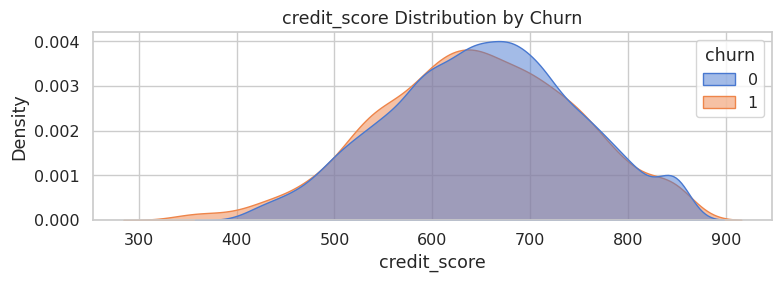

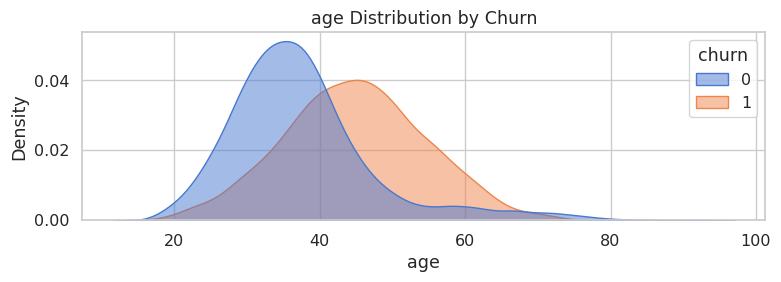

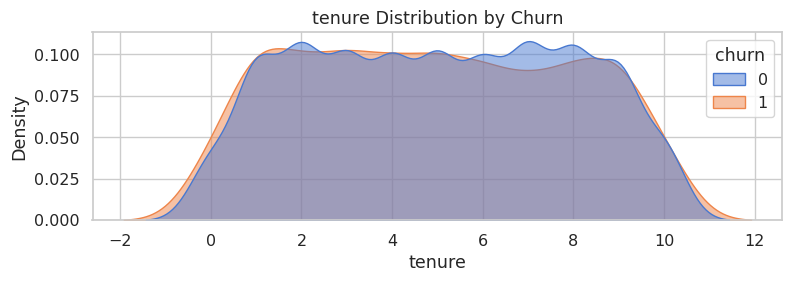

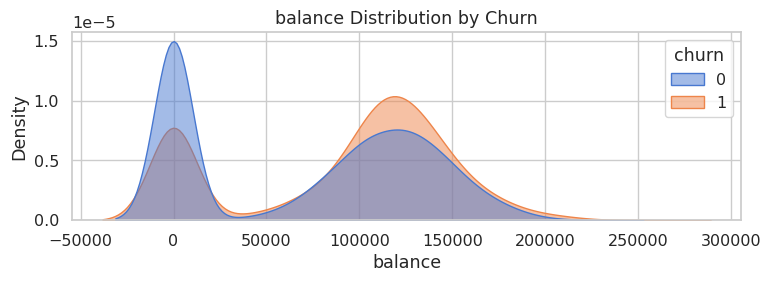

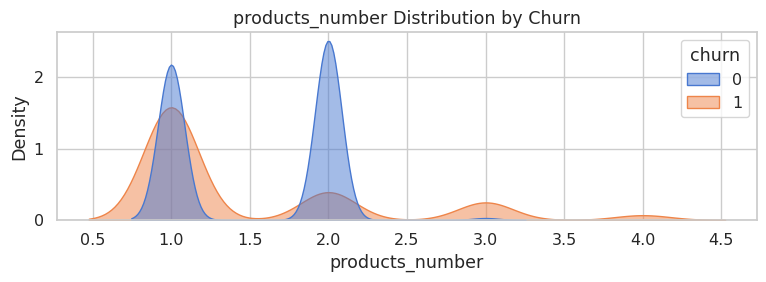

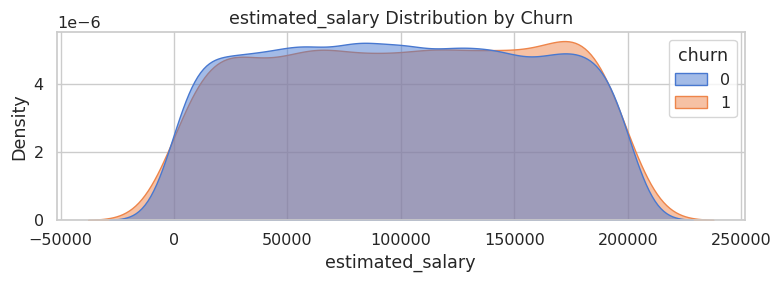

In [21]:
#Distribution Plots (KDE)

for col in num_cols:
  plt.figure(figsize = (8,3))
  sns.kdeplot(data = df, x=col, hue = 'churn', fill = True, common_norm=False, alpha = 0.5)
  plt.title(f'{col} Distribution by Churn')
  plt.tight_layout()
  plt.show()

#**Histplot**

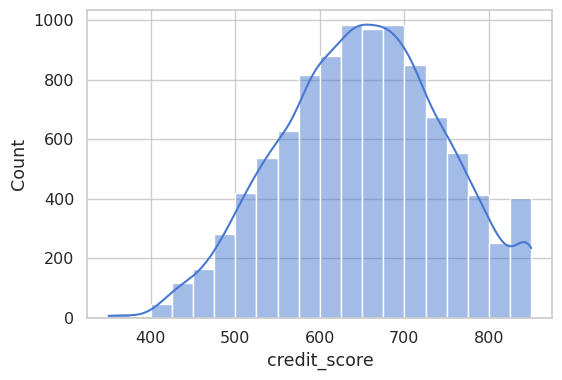

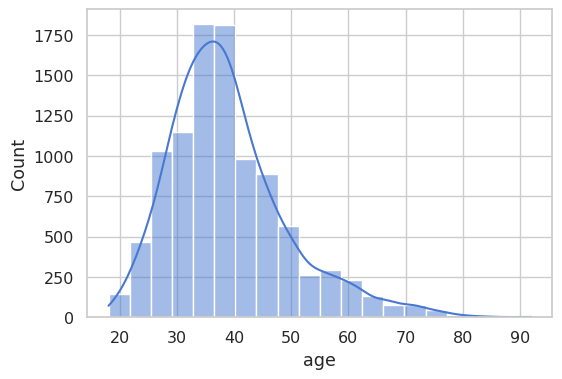

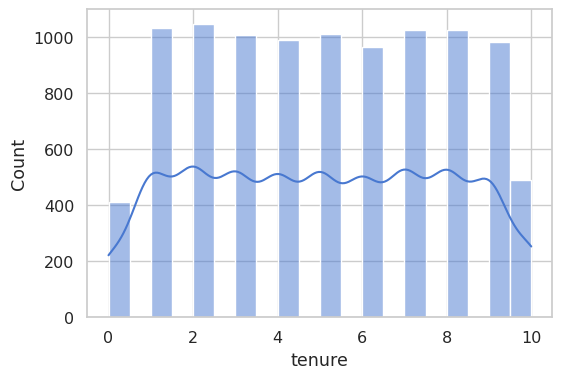

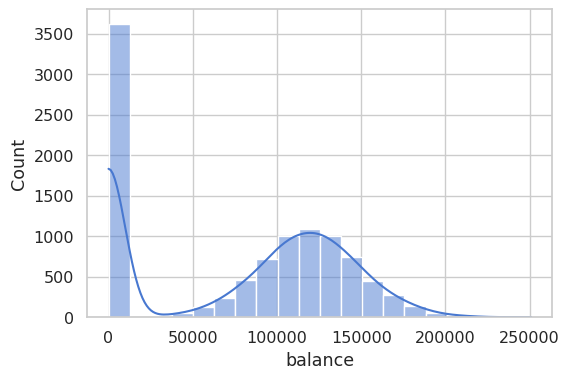

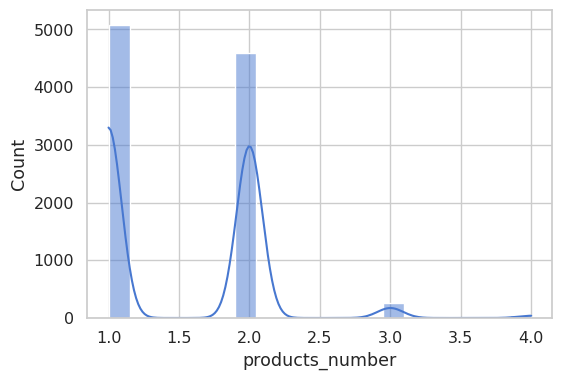

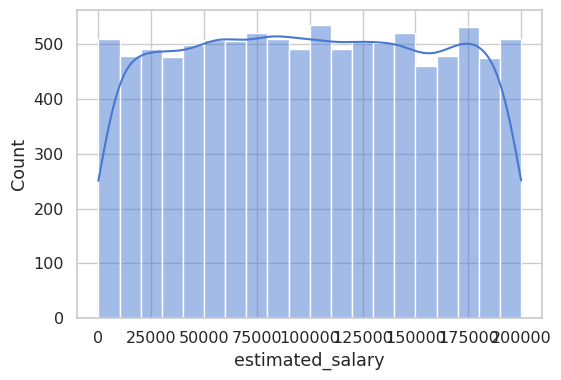

In [22]:
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde = True,bins = 20)

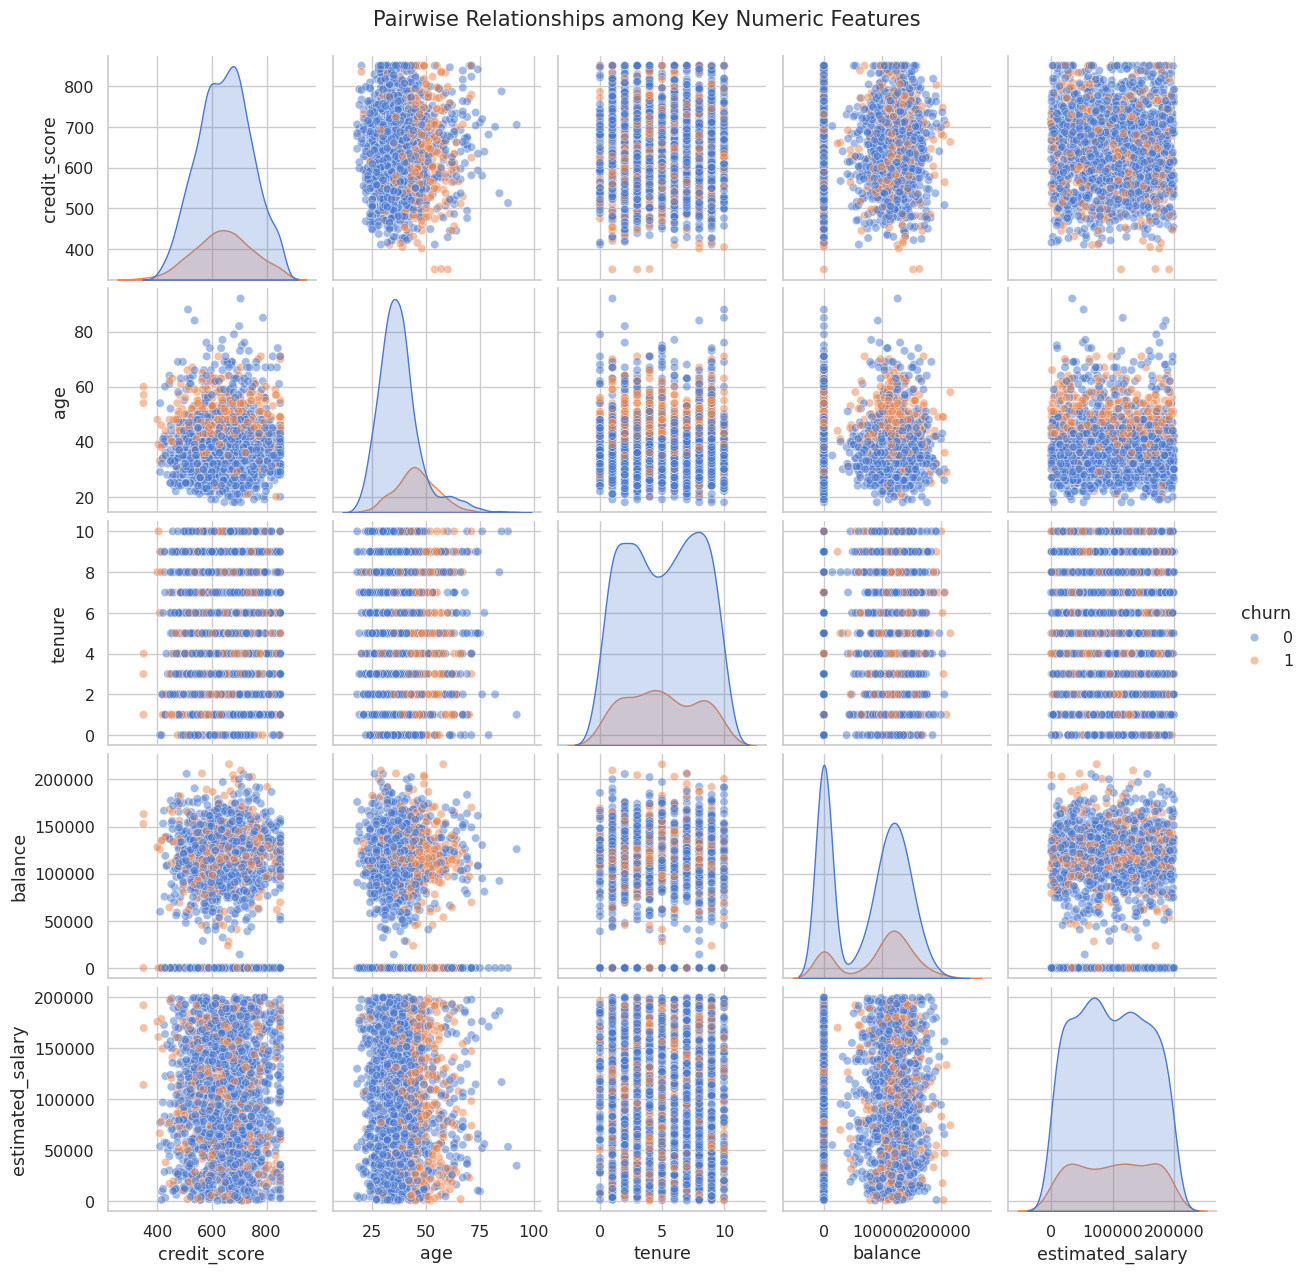

In [27]:
#Pairplot (sampled for speed)


sns.pairplot(
    df.sample(frac=0.2, random_state=42),
    vars=['credit_score', 'age', 'tenure', 'balance', 'estimated_salary'],hue='churn',diag_kind='kde',
    plot_kws={'alpha': 0.5})

plt.suptitle('Pairwise Relationships among Key Numeric Features',y=1.02)

plt.show()

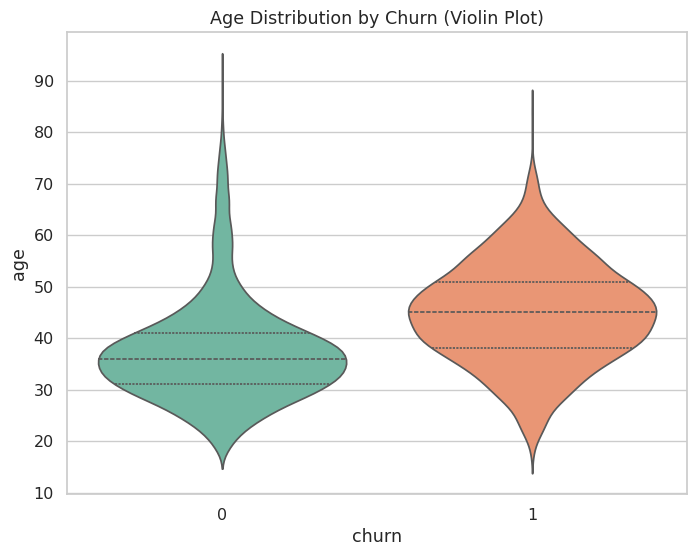

In [28]:
#Violin plot for Age

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x='churn', y='age', inner='quart', palette= 'Set2')
plt.title('Age Distribution by Churn (Violin Plot)')
plt.show()

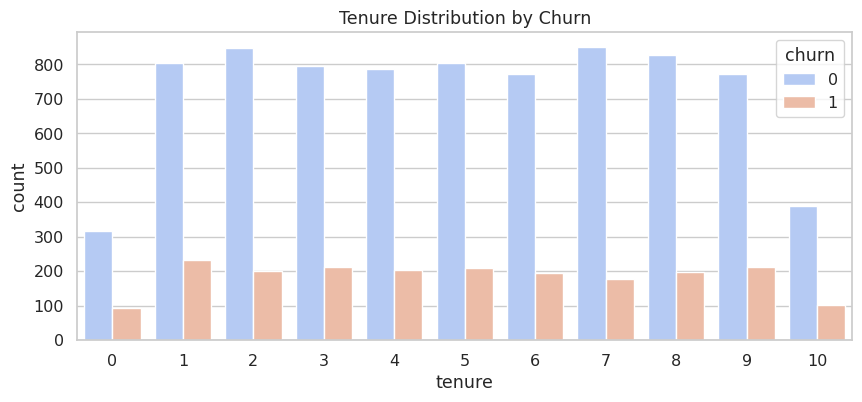

In [29]:
#Trnure Distribution

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='tenure', hue='churn', palette='coolwarm')
plt.title('Tenure Distribution by Churn')
plt.show()

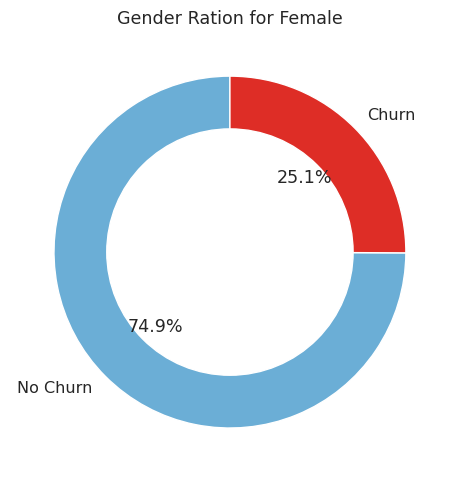

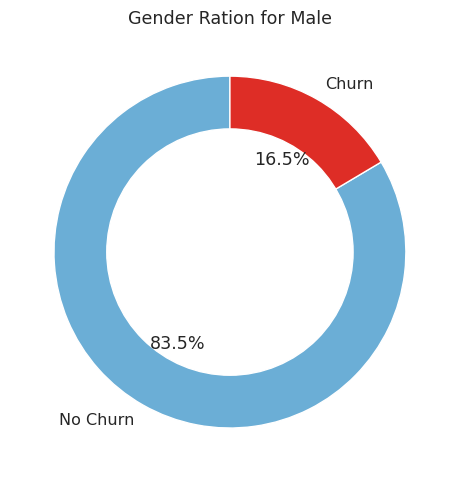

In [32]:
#Gender VS churn Donut Chart

gender_counts = df.groupby('gender')['churn'].value_counts(normalize = True).unstack().fillna(0)
for gender in gender_counts.index:
  plt.figure(figsize=(5,5))
  plt.pie(gender_counts.loc[gender], labels = ['No Churn', 'Churn'],
          autopct = '%1.1f%%', startangle= 90, colors = ['#6baed6', '#de2d26'])
  center = plt.Circle((0,0), 0.7, fc = 'white')
  fig = plt.gcf()
  fig.gca().add_artist(center)
  plt.title(f'Gender Ration for {gender}')
  plt.tight_layout()
  plt.show()

In [34]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

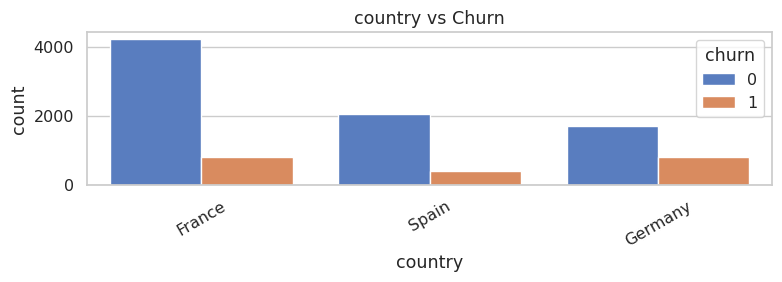

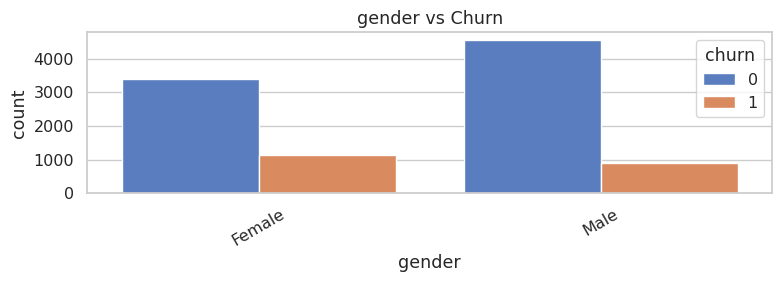

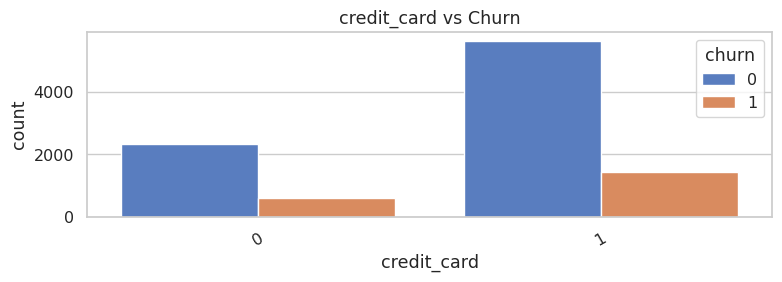

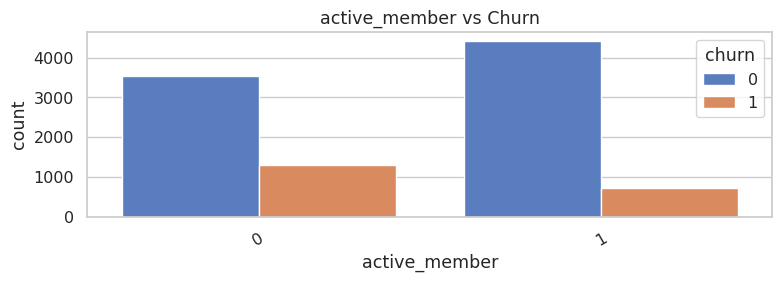

In [35]:
#Catagorical Feature

cat_cols = ['country','gender','credit_card', 'active_member']
for c in cat_cols:
  plt.figure(figsize=(8,3))
  sns.countplot(data=df, x=c, hue='churn')
  plt.title(f'{c} vs Churn')
  plt.xticks(rotation= 30)
  plt.tight_layout()
  plt.show()

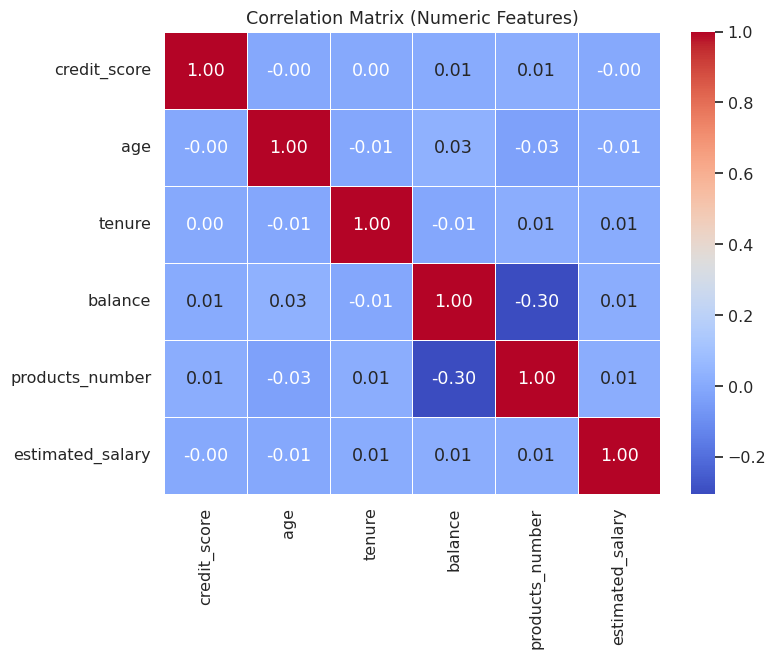

In [49]:
#Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm',fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

In [53]:
#Numeric Correllation Heatmap

numeric_data = df[num_cols]
corr_matrix = numeric_data.corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

,credit_score,age,tenure,balance,products_number,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


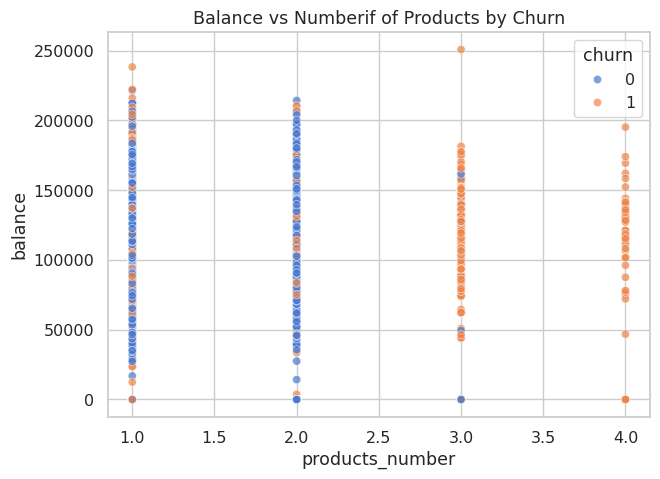

In [57]:
#Balance vs Product scatter

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='products_number', y='balance', hue='churn', alpha = 0.7)
plt.title('Balance vs Numberif of Products by Churn')
plt.show()

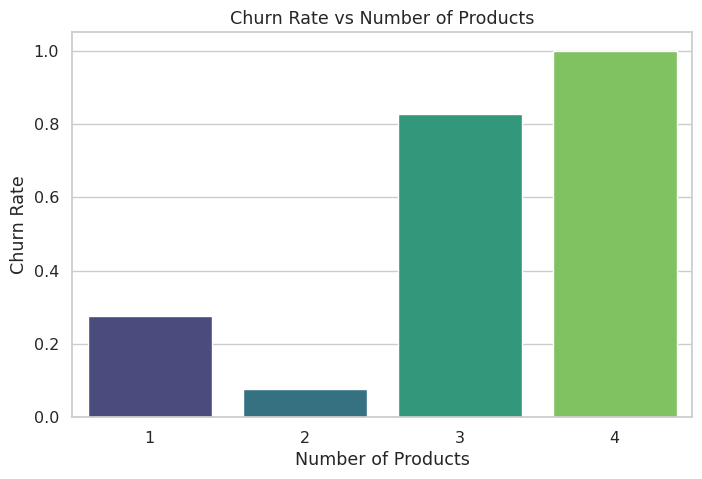

In [60]:
#Aggregate churn rate per number products

churn_rate =df.groupby('products_number')['churn'].mean().reset_index()

#plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate, x='products_number', y='churn', palette='viridis')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate vs Number of Products')
plt.show()

#**Feature Engineering**

In [71]:
# Feature Engineering

df_fe = df.copy()

# Balance Per Product
df_fe['balance_per_product'] = (
    df_fe['balance'] / df_fe['products_number'].replace(0, np.nan)
)

df_fe['balance_per_product'] = (
    df_fe['balance_per_product'].fillna(0)
)


# Salary to Balance Ratio
df_fe['salary_balance_ratio'] = (
    df_fe['estimated_salary'] / df_fe['balance'].replace(0, np.nan)
)

df_fe['salary_balance_ratio'] = (
    df_fe['salary_balance_ratio']
    .replace([np.inf, -np.inf], np.nan)
)

df_fe['salary_balance_ratio'] = (
    df_fe['salary_balance_ratio']
    .fillna(df_fe['salary_balance_ratio'].median())
)


# Age Group
bins = [0, 25, 35, 45, 55, 65, 100]

labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

df_fe['age_group'] = pd.cut(
    df_fe['age'],
    bins=bins,
    labels=labels,
    right=False
)


# Tenure Bucket
df_fe['tenure_bucket'] = pd.cut(
    df_fe['tenure'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['0', '1-2', '3-5', '6-10', '10+']
)


# High Balance Flag
df_fe['high_balance'] = (
    df_fe['balance'] > df_fe['balance'].quantile(0.75)
).astype(int)


# Quick Check
df_fe[
    [
        'balance_per_product',
        'salary_balance_ratio',
        'age',
        'age_group',
        'tenure_bucket',
        'high_balance'
    ]
].head()

,balance_per_product,salary_balance_ratio,age,age_group,tenure_bucket,high_balance
0,0.000000,0.839258,42,35-44,1-2,0
1,83807.860000,1.342864,41,35-44,1-2,0
2,53220.266667,0.713585,42,35-44,6-10,1
3,0.000000,0.839258,39,35-44,1-2,0
4,125510.820000,0.630098,43,35-44,1-2,0


#**Preprocessing - encoding & scaling**


In [72]:
# Define features and target
target = 'churn'
drop_cols = ['customer_id']
features = [c for c in df_fe.columns if c not in [target] + drop_cols]

numeric_features = ['credit_score','age','tenure','balance','products_number','estimated_salary',
                    'balance_per_product','salary_balance_ratio']
categorical_features = ['country','gender','credit_card','active_member','age_group','tenure_bucket','high_balance']

df_fe[categorical_features] = df_fe[categorical_features].astype('object')

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']


#**Train Test Split**

In [75]:
X = df_fe[features]
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train churn proportion:', y_train.mean(), 'Test churn proportion:', y_test.mean())

Train shape: (8000, 15) Test shape: (2000, 15)
Train churn proportion: 0.20375 Test churn proportion: 0.2035


#**Train Multiple models with a pipeline and compare using cross-validation**

In [76]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    print(f"{name} AUC: Mean={scores.mean():.4f} Std={scores.std():.4f}")

LogisticRegression AUC: Mean=0.7878 Std=0.0245
RandomForest AUC: Mean=0.8504 Std=0.0141
GradientBoosting AUC: Mean=0.8623 Std=0.0098
AdaBoost AUC: Mean=0.8464 Std=0.0136
SVC AUC: Mean=0.8348 Std=0.0077


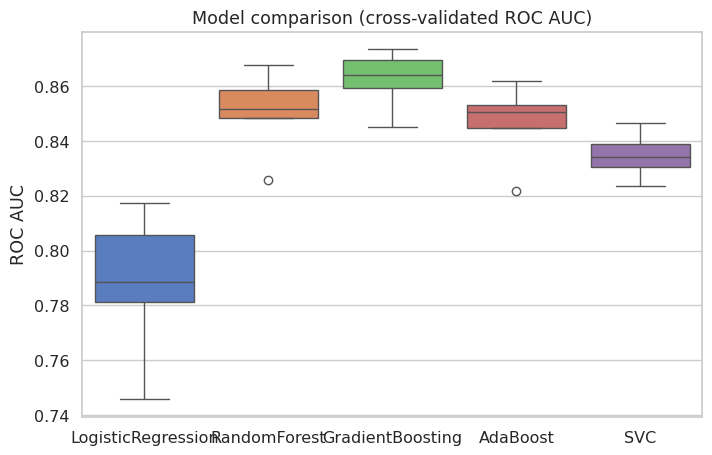

In [77]:
# Boxplot of CV AUC scores
plt.figure(figsize=(8,5))
sns.boxplot(data=[results[m] for m in list(results.keys())])
plt.xticks(ticks=range(len(results)), labels=list(results.keys()))
plt.ylabel('ROC AUC')
plt.title('Model comparison (cross-validated ROC AUC)')
plt.show()

#**Fit best model on full train set and evaluate on test set**

In [78]:
# Choose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

('GradientBoosting', np.float64(0.8623318180504859))

Test Accuracy: 0.8640
Test Precision: 0.7647
Test Recall: 0.4791
Test F1-score: 0.5891
Test ROC AUC: 0.8704

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



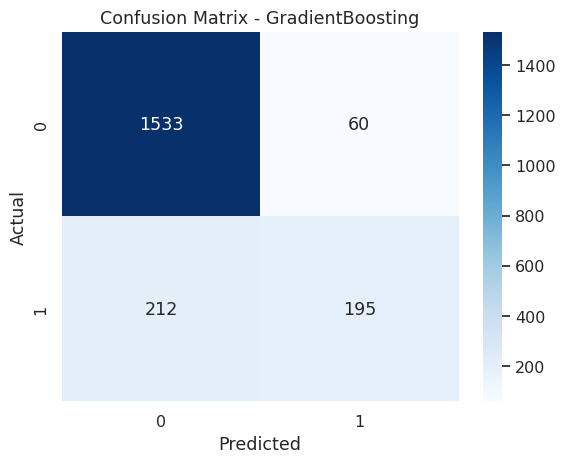

In [79]:
best_model = models[best_name]
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', best_model)])
best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test ROC AUC: {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

#**Feature importance (if applicable)**

,0
age,0.338255
products_number,0.261380
balance_per_product,0.061191
balance,0.057287
active_member_0,0.052672
active_member_1,0.051059
country_Germany,0.049499
salary_balance_ratio,0.029302
estimated_salary,0.028477
credit_score,0.024923


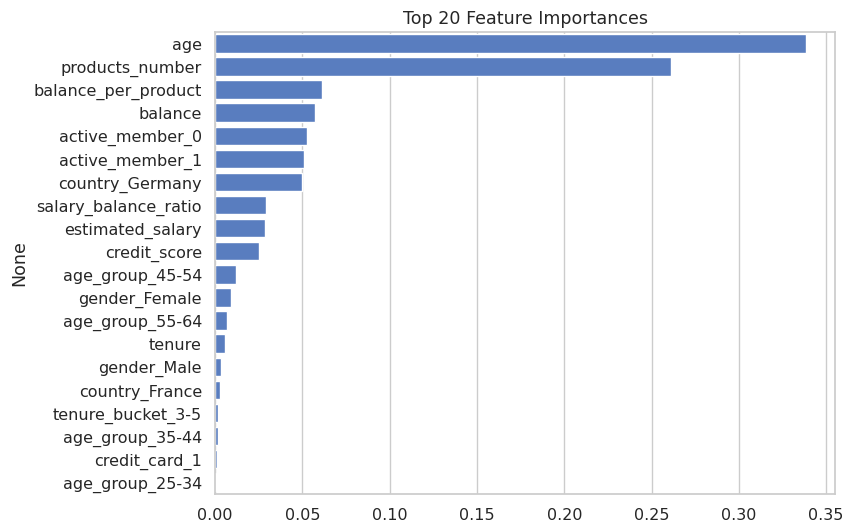

In [80]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    num_feats = numeric_features
    cat_feats = list(best_pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features))
    feature_names = num_feats + cat_feats
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]
    display(fi)
    plt.figure(figsize=(8,6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title('Top 20 Feature Importances')
    plt.show()
else:
    print('Selected model does not provide feature_importances_ attribute.')

#**Save the best pipeline and preprocessing artifacts**

In [81]:
joblib.dump(best_pipeline, 'best_churn_pipeline.pkl')
print("Saved pipeline: best_churn_pipeline.pkl")

Saved pipeline: best_churn_pipeline.pkl


#**Example: Predict churn for a new customer**

In [82]:
# --- New customer sample ---
sample = {
    'customer_id': 373292028,
    'credit_score': 650,
    'country': 'France',
    'gender': 'Male',
    'age': 40,
    'tenure': 3,
    'balance': 50000.0,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000.0
}

sample_df = pd.DataFrame([sample])

# --- Apply same feature engineering ---
sample_df['balance_per_product'] = sample_df['balance'] / (sample_df['products_number'].replace(0, np.nan))
sample_df['balance_per_product'].fillna(0, inplace=True)

sample_df['salary_balance_ratio'] = sample_df['estimated_salary'] / (sample_df['balance'].replace(0, np.nan))
sample_df['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
sample_df['salary_balance_ratio'].fillna(sample_df['salary_balance_ratio'].median(), inplace=True)

bins = [0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
sample_df['age_group'] = pd.cut(sample_df['age'], bins=bins, labels=labels)

sample_df['tenure_bucket'] = pd.cut(sample_df['tenure'], bins=[-1,0,2,5,10,100], labels=['0','1-2','3-5','6-10','10+'])
sample_df['high_balance'] = (sample_df['balance'] > 50000.0).astype(int)  # can use 75th percentile of training set


# --- Drop ID ---
sample_df = sample_df.drop(columns=['customer_id'])

# --- Predict ---
pred = best_pipeline.predict(sample_df)[0]
prob = best_pipeline.predict_proba(sample_df)[0,1]

print(f'Predicted churn: {pred}, probability of churn: {prob:.3f}')

Predicted churn: 0, probability of churn: 0.030
